# In-class exercise

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import os
import tensorflow as tf;
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
sns.set_style('whitegrid')

In [14]:
data = "/workspaces/Big_Data_Applications/Datasets/concrete_data.csv"
df = pd.read_csv(data)
print(df.shape)
# df.head()

(1030, 9)


In [40]:
# First, we split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
                                    df.drop(['concrete_compressive_strength'],axis=1),
                                    df['concrete_compressive_strength'],
                                    test_size=0.2,
                                    random_state=0
                                    )
print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

* Train set: (824, 8) (824,) 
* Test set: (206, 8) (206,)


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
                                    X_train,
                                    y_train,
                                    test_size=0.2,
                                    random_state=0
                                    )

print("* Train set:", X_train.shape, y_train.shape)
print("* Validation set:",  X_val.shape, y_val.shape)
print("* Test set:",   X_test.shape, y_test.shape)

* Train set: (659, 8) (659,)
* Validation set: (165, 8) (165,)
* Test set: (206, 8) (206,)


In [17]:
def pipeline_pre_processing():
    """
    Define data preparation pipeline
    """
    pipeline_base = Pipeline([

      ( "feat_scaling", StandardScaler() )

    ])
    return pipeline_base

In [18]:
pipeline = pipeline_pre_processing()
X_train = pipeline.fit_transform(X_train)
X_val= pipeline.transform(X_val)
X_test = pipeline.transform(X_test)

In [19]:
def create_tf_model(n_features):

  model = Sequential()
  model.add(Dense(units=n_features, activation='relu', input_shape=(n_features,)))

  model.add(Dense(units=8,activation='relu'))
  model.add(Dropout(0.25))

  model.add(Dense(units=4,activation='relu'))
  model.add(Dropout(0.25))

  model.add(Dense(units=1))
  model.compile(loss='mse', optimizer='adam')

  return model

In [20]:
"""
class TFModel(tf.Module):

    def __init__(self, n_features):

        # Layer 1
        self.w1 = tf.Variable(tf.random.normal([n_features, n_features]))
        self.b1 = tf.Variable(tf.zeros([n_features]))

        # Layer 2
        self.w2 = tf.Variable(tf.random.normal([n_features, 8]))
        self.b2 = tf.Variable(tf.zeros([8]))

        # Layer 3
        self.w3 = tf.Variable(tf.random.normal([8, 4]))
        self.b3 = tf.Variable(tf.zeros([4]))

        # Output layer
        self.w4 = tf.Variable(tf.random.normal([4, 1]))
        self.b4 = tf.Variable(tf.zeros([1]))

    def __call__(self, x, training=True):

        # Layer 1
        x = tf.matmul(x, self.w1) + self.b1
        x = tf.nn.relu(x)

        # Layer 2
        x = tf.matmul(x, self.w2) + self.b2
        x = tf.nn.relu(x)

        if training:
            x = tf.nn.dropout(x, rate=0.25)

        # Layer 3
        x = tf.matmul(x, self.w3) + self.b3
        x = tf.nn.relu(x)

        if training:
            x = tf.nn.dropout(x, rate=0.25)

        # Output
        x = tf.matmul(x, self.w4) + self.b4

        return x
    """

'\nclass TFModel(tf.Module):\n\n    def __init__(self, n_features):\n\n        # Layer 1\n        self.w1 = tf.Variable(tf.random.normal([n_features, n_features]))\n        self.b1 = tf.Variable(tf.zeros([n_features]))\n\n        # Layer 2\n        self.w2 = tf.Variable(tf.random.normal([n_features, 8]))\n        self.b2 = tf.Variable(tf.zeros([8]))\n\n        # Layer 3\n        self.w3 = tf.Variable(tf.random.normal([8, 4]))\n        self.b3 = tf.Variable(tf.zeros([4]))\n\n        # Output layer\n        self.w4 = tf.Variable(tf.random.normal([4, 1]))\n        self.b4 = tf.Variable(tf.zeros([1]))\n\n    def __call__(self, x, training=True):\n\n        # Layer 1\n        x = tf.matmul(x, self.w1) + self.b1\n        x = tf.nn.relu(x)\n\n        # Layer 2\n        x = tf.matmul(x, self.w2) + self.b2\n        x = tf.nn.relu(x)\n\n        if training:\n            x = tf.nn.dropout(x, rate=0.25)\n\n        # Layer 3\n        x = tf.matmul(x, self.w3) + self.b3\n        x = tf.nn.relu(x)\n\

In [21]:
X_train.shape[1]

8

In [22]:
model = create_tf_model(n_features=X_train.shape[1])
model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
import graphviz
plot_model(model, show_shapes=True, dpi=80)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [38]:
early_stop = EarlyStopping(monitor='age_loss', mode='min', verbose=1, patience=15)

In [39]:
model.fit(x=X_train,
          y=y_train,
          epochs=100,
          validation_data=(X_val, y_val),
          verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/100


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2662.2488 - val_loss: 1886.7662
Epoch 2/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - loss: 951.0692

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `age_loss` which is not available. Available metrics are: loss,val_loss
  current = self.get_monitor_value(logs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2447.9580 - val_loss: 1872.0631
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2690.8794 - val_loss: 1884.3087
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2544.9443 - val_loss: 1889.3500
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2668.0046 - val_loss: 1874.7098
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2741.2361 - val_loss: 1881.7219
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2496.0432 - val_loss: 1875.7140
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2503.6992 - val_loss: 1855.8528
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2412.6921 - val_loss: 1852.8743
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2498.9902 - val_loss: 1840.7222
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2407.4744 - val_loss: 1864.3369
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2469.2976 - val_loss: 1855.7819
Epoch 13

In [29]:
losses = pd.DataFrame(model.history.history)
losses

,loss,val_loss
0,6042.366699,5348.255371
1,6018.890625,5321.087891
2,5984.768066,5285.156250
3,5962.038086,5243.084961
4,5914.634766,5191.916992
...,...,...
95,2797.819092,1912.513794
96,2735.888916,1923.443237
97,2450.627686,1908.524414
98,2877.848877,1911.360229


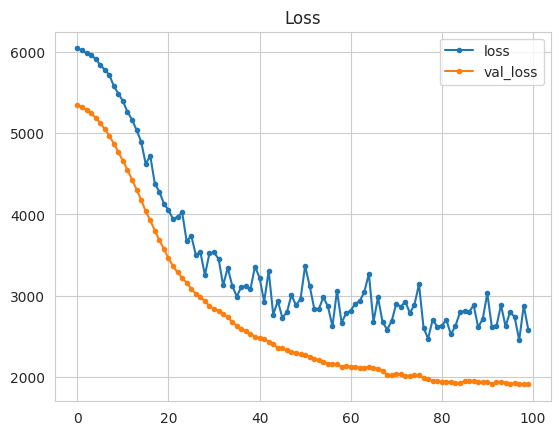

In [30]:
sns.set_style("whitegrid")
losses[['loss','val_loss']].plot(style='.-')
plt.title("Loss")
plt.show()

In [31]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2396.1782


2396.17822265625

In [32]:
def regression_performance(X_train, y_train,
                           X_val, y_val,
                           X_test, y_test,pipeline):
    """
    Assessment of performance of CNN regression model
    """
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train,y_train,pipeline)
    print("* Validation Set")
    regression_evaluation(X_val, y_val,pipeline)
    print("* Test Set")
    regression_evaluation(X_test,y_test,pipeline)

def regression_evaluation(X, y, pipeline):
    """
    Gets features and target (either from train or test set) and pipeline.
    - Predicts using the pipeline and the features
    - Calculates performance metrics comparing the prediction to the target
    """
    prediction = pipeline.predict(X)
    print('R2 Score:', round(r2_score(y, prediction), 3))
    print('Mean Absolute Error:', round(mean_absolute_error(y, prediction), 3))
    print('Mean Squared Error:', round(mean_squared_error(y, prediction), 3))
    print('Root Mean Squared Error:', round(np.sqrt(mean_squared_error(y, prediction)), 3))
    print("\n")
    

def regression_evaluation_plots(X_train, y_train,
                                X_val, y_val,
                                X_test, y_test,
                                pipeline, alpha_scatter=0.5):
    """
    Plot regression evaluation
    """
    pred_train = pipeline.predict(X_train).reshape(-1)
    # we reshape the prediction arrays to be in the format (n_rows,), so we can plot it after
    pred_val = pipeline.predict(X_val).reshape(-1)
    pred_test = pipeline.predict(X_test).reshape(-1)
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,6))
    
    sns.scatterplot(x=y_train , y=pred_train, alpha=alpha_scatter, ax=axes[0])
    
    sns.lineplot(x=y_train , y=y_train, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")
    
    sns.scatterplot(x=y_val , y=pred_val, alpha=alpha_scatter, ax=axes[1])
    
    sns.lineplot(x=y_val , y=y_val, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Validation Set")
    
    sns.scatterplot(x=y_test , y=pred_test, alpha=alpha_scatter, ax=axes[2])
    sns.lineplot(x=y_test , y=y_test, color='red', ax=axes[2])
    axes[2].set_xlabel("Actual")
    axes[2].set_ylabel("Predictions")
    axes[2].set_title("Test Set")
    
    plt.show()

Model Evaluation 

* Train Set
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2 Score: 0.484
Mean Absolute Error: 22.715
Mean Squared Error: 1995.808
Root Mean Squared Error: 44.674


* Validation Set
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
R2 Score: 0.471
Mean Absolute Error: 20.646
Mean Squared Error: 1905.942
Root Mean Squared Error: 43.657


* Test Set
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
R2 Score: 0.486
Mean Absolute Error: 24.257
Mean Squared Error: 2396.178
Root Mean Squared Error: 48.951


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


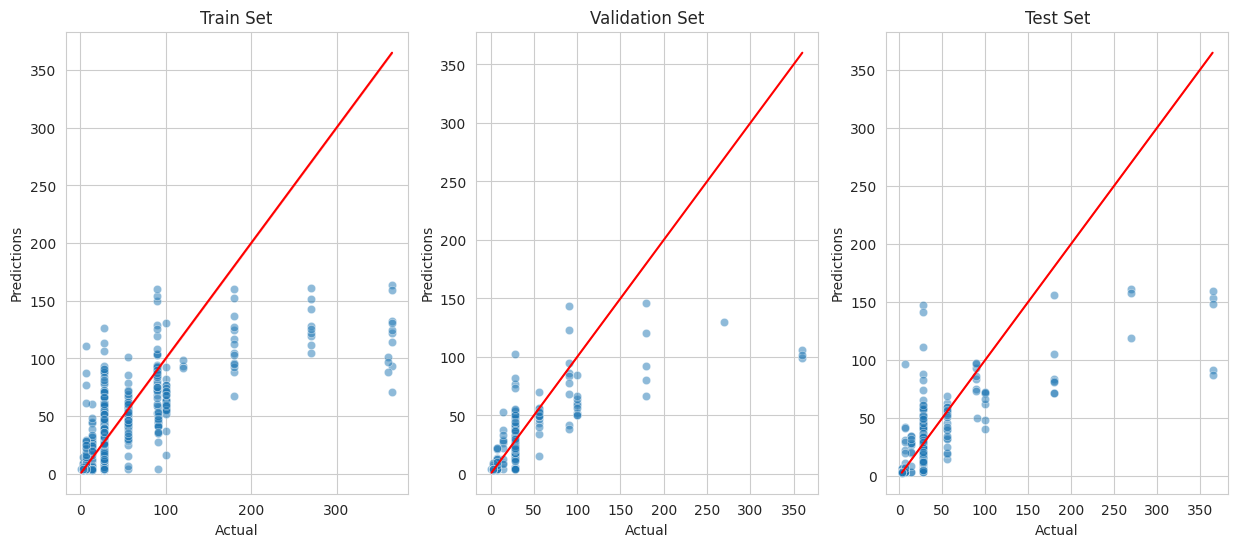

In [33]:
regression_performance(X_train, y_train,X_val, y_val, X_test, y_test,model)
regression_evaluation_plots(X_train, y_train, X_val, y_val,X_test, y_test,
                            model, alpha_scatter=0.5)

In [34]:
X_test.shape

(206, 8)

In [35]:
sample = pd.DataFrame({
    'MedInc': [8.325200],
    'HouseAge': [41.000000],
    'AveRooms': [6.984127],
    'AveBedrms': [1.023810],
    'Population': [322.000000],
    'AveOccup': [2.555556],
    'Latitude': [37.880000],
    'Longitude': [-122.230000] 
})

sample

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23


In [36]:
sample_cnn = pipeline.transform(sample.values)
sample_cnn

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ -2.5630784 ,  -0.40940439,  -0.73858193,  -8.31619593,
         52.69738342, -12.41227214,  -8.8217338 ,  -9.33809339]])

In [37]:
predicted_price = model.predict(sample_cnn)[0][0]
print('---------------')
print(f"Predicted house price based on the information provided is: {predicted_price:.2f} arb. units.")
print('---------------')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
---------------
Predicted house price based on the information provided is: 3.96 arb. units.
---------------
